# 📊 Matplotlib for CA Professionals
**Turning Financial Data into Powerful Charts**

---

**Pre-requisite:** Module 3 — Pandas  
**Estimated time:** 4–5 hours  
**Session structure:** Why Visualise → What is Matplotlib → Architecture → Interface → Chart Selection → Hands-on

---

## 📋 Table of Contents

| Part | Section | Topic |
|------|---------|-------|
| **Part 1: Why Matplotlib?** | 1 | The Power of Visual Communication in Finance |
| | 2 | What is Matplotlib? — History & Position |
| **Part 2: Fundamentals** | 3 | The Figure / Axes Architecture |
| | 4 | Two Interfaces: pyplot vs Object-Oriented |
| | 5 | Chart Selection Guide |
| **Part 3: Hands-on** | 6 | Installing & Setup |
| | 7 | Anatomy of a Chart |
| | 8 | Line Chart — Revenue Trend |
| | 9 | Bar Chart — Expense Comparison |
| | 10 | Horizontal Bar Chart |
| | 11 | Grouped Bar — Budget vs Actual |
| | 12 | Pie & Donut Chart — Revenue Mix |
| | 13 | Histogram — Invoice Distribution |
| | 14 | Scatter Plot — Profit vs Revenue |
| | 15 | Subplots — Financial Dashboard |
| | 16 | Styling & Formatting |
| | 17 | Saving Charts |
| **Part 4: Practice** | 18 | Practice Exercises |

---

## Part 1: Why Matplotlib?

## Section 1: The Power of Visual Communication in Finance

### Your brain processes charts 60,000× faster than tables

Humans evolved to detect patterns visually. A column of 500 numbers is noise. The same data as a line chart reveals a story — instantly.

Consider these two ways to present the same information:

**Option A — Table:**
```
Apr: NPR 12.5L | May: NPR 13.8L | Jun: NPR 11.2L | Jul: NPR 14.5L | Aug: NPR 16.2L | Sep: NPR 17.8L
Oct: NPR 15.5L | Nov: NPR 14.2L | Dec: NPR 16.8L | Jan: NPR 19.1L | Feb: NPR 20.3L | Mar: NPR 21.5L
```

**Option B — Line chart:** A smooth upward curve with a Q1 dip, Q2–Q3 plateau, Q4 surge.

Option B tells a board of directors in 3 seconds that Q4 was exceptional and Q1 needs attention.

### Where financial professionals use charts

| Context | Chart use |
|---------|-----------|
| Board presentations | Revenue trend, profit waterfall, budget vs actual |
| Audit reports | Invoice distribution, outlier scatter plots, Benford's Law histogram |
| SEBON / NRB filings | Time-series, ratio trends, comparative bar charts |
| CA certificate appendices | P&L bridge charts, segment mix donut |
| Management dashboards | Multi-panel (Revenue + Expenses + Margin + YTD) |
| Tax planning | Slab-wise liability bar charts, effective rate trends |

### The CA's competitive advantage

A CA who can create a professional chart in 10 lines of Python — rather than manually formatting an Excel chart for 30 minutes — has a significant efficiency advantage. More importantly, a Python chart can be **regenerated instantly** when the data changes, with no manual reformatting.

> **The goal of this module:** Build every chart type you need for CA practice, with full control over formatting, labels, and export.

## Section 2: What is Matplotlib? — History & Position

### The Origin Story

In **2003**, **John D. Hunter** — a neuroscientist at the University of Chicago — was analysing epilepsy data. He was using MATLAB (a proprietary numerical computing environment that costs thousands of dollars per licence). He wanted to migrate to Python but Python had no charting library.

So he built one, modelling it closely after MATLAB's plotting interface, and named it **Matplotlib**.

> *"I wrote Matplotlib initially to visualise electrocorticography (ECoG) data from epilepsy patients."*  
> — John D. Hunter, 2012 (Hunter passed away that year; the library is now maintained by NumFOCUS)

Matplotlib was open-sourced immediately and became the standard Python visualization library. Today it has over **40 million downloads per month**.

### Where Matplotlib sits in the Python ecosystem

```
                    ┌──────────────────────────────────────────────────────────┐
  Visualization     │  Seaborn   Plotly   Bokeh   Pandas .plot()  GeoPandas  │
  libraries         │         (all built on top of Matplotlib or parallel)    │
                    ├──────────────────────────────────────────────────────────┤
                    │                   Matplotlib                              │ ← Core viz engine
                    ├──────────────────────────────────────────────────────────┤
                    │                     NumPy                                 │ ← Numerical engine
                    └──────────────────────────────────────────────────────────┘
```

Matplotlib is the **foundation**. Seaborn (Module 5) is built on top of Matplotlib and makes statistical charts easier. But Matplotlib gives you **complete control** — which is essential for professional financial charts.

### What Matplotlib can produce

| Category | Examples |
|----------|---------|
| Statistical | Histograms, box plots, scatter plots, error bars |
| Time-series | Line charts with date axes, candlestick charts |
| Categorical | Bar charts (grouped, stacked, horizontal), pie charts |
| Financial | Waterfall, Gantt, OHLC candlestick |
| Scientific | Heatmaps, contour plots, 3D surfaces |
| Dashboards | Multi-panel figures with subplots |

## Part 2: Matplotlib Fundamentals

## Section 3: The Figure / Axes Architecture

The single most important concept in Matplotlib is its **object hierarchy**: Figure → Axes → Artists.

### The three-level hierarchy

```
┌─────────────────────── Figure (the full canvas — the A4 paper) ─────────────────────────┐
│                                                                                          │
│   ┌──────────────────── Axes (one plot area) ────────────────────────────────────────┐  │
│   │                                                                                  │  │
│   │   Title                                                                          │  │
│   │                                                                                  │  │
│   │   Y-axis   ──── Artist objects ────────────────────────────────────────────      │  │
│   │   label   (Lines, Bars, Patches, Text, Markers, Grid lines, Tick marks…)         │  │
│   │                                                                                  │  │
│   │                          X-axis label                                            │  │
│   └──────────────────────────────────────────────────────────────────────────────────┘  │
│                                   Legend (attached to Figure or Axes)                    │
└──────────────────────────────────────────────────────────────────────────────────────────┘
```

### Level 1: Figure

The **Figure** is the entire window or page. Think of it as the blank A4 sheet of paper.

- Created with: `fig = plt.figure()` or `fig, ax = plt.subplots()`
- Controls: overall size (`figsize`), resolution (`dpi`), background colour
- A Figure can contain **multiple Axes** (subplots — this is why we call `plt.subplots()`)

### Level 2: Axes

The **Axes** is the actual chart area — the space where data is plotted.

- One Figure → one or more Axes
- Each Axes has its own X-axis, Y-axis, title, legend
- Created with: `fig, ax = plt.subplots()` (one Axes) or `fig, axes = plt.subplots(2, 2)` (grid)

### Level 3: Artists

**Artists** are everything you can see on the Axes:
- Lines (`Line2D`): `ax.plot()`
- Rectangles (`Rectangle`): `ax.bar()`
- Text (`Text`): `ax.set_title()`, `ax.annotate()`
- Markers, tick labels, grid lines, spines — all Artists

> **Why this matters:** Once you understand Figure → Axes → Artists, every Matplotlib command makes sense. `ax.set_title()` sets the title of the Axes. `fig.suptitle()` sets the title of the Figure. `fig.set_size_inches()` resizes the canvas.

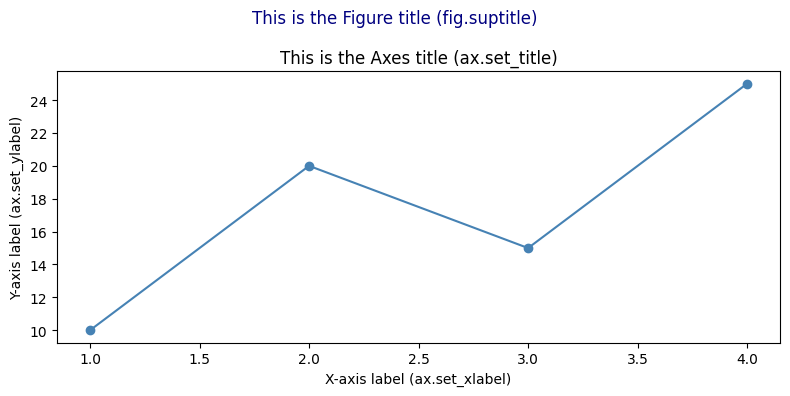

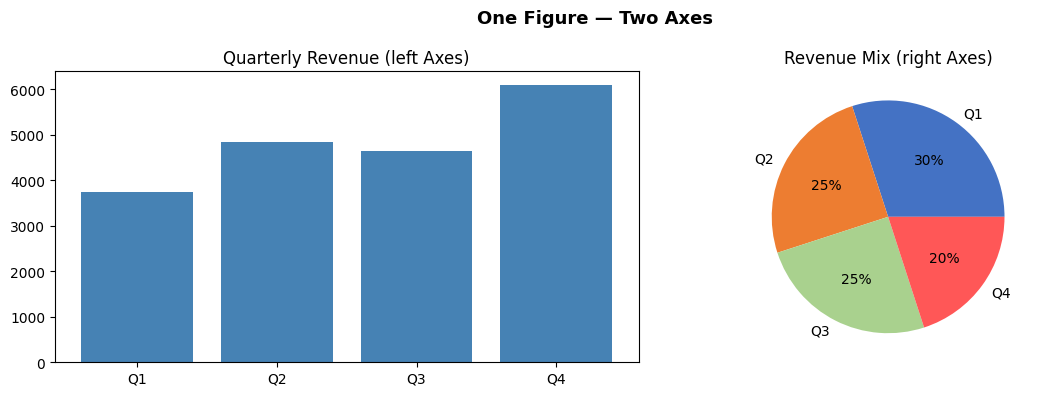

Key insight: fig controls the canvas; ax controls the chart.
fig type: <class 'matplotlib.figure.Figure'>
ax type:  <class 'matplotlib.axes._axes.Axes'>


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Demonstrating the Figure/Axes hierarchy ---

# 1. Single Axes on one Figure
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot([1, 2, 3, 4], [10, 20, 15, 25], color='steelblue', marker='o')
ax1.set_title('This is the Axes title (ax.set_title)')
fig1.suptitle('This is the Figure title (fig.suptitle)', fontsize=12, color='navy')
ax1.set_xlabel('X-axis label (ax.set_xlabel)')
ax1.set_ylabel('Y-axis label (ax.set_ylabel)')
plt.tight_layout()
plt.show()

# 2. Multiple Axes on one Figure (2 columns)
fig2, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4))

ax_left.bar(['Q1','Q2','Q3','Q4'], [3750, 4850, 4650, 6090], color='steelblue')
ax_left.set_title('Quarterly Revenue (left Axes)')

ax_right.pie([30, 25, 25, 20], labels=['Q1','Q2','Q3','Q4'], autopct='%1.0f%%',
             colors=['#4472C4','#ED7D31','#A9D18E','#FF5757'])
ax_right.set_title('Revenue Mix (right Axes)')

fig2.suptitle('One Figure — Two Axes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: fig controls the canvas; ax controls the chart.")
print(f"fig type: {type(fig2)}")
print(f"ax type:  {type(ax_left)}")

## Section 4: Two Interfaces — pyplot vs Object-Oriented

Matplotlib has two ways to create charts. Understanding the difference prevents confusion.

### Interface 1: pyplot (implicit state machine)

```python
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [10, 20, 15])
plt.title('My Chart')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
```

- Simple, looks like MATLAB
- Works fine for single, simple charts
- **Problem:** With subplots, `plt.title()` doesn't know WHICH subplot to title — ambiguous

### Interface 2: Object-Oriented (explicit, professional)

```python
fig, ax = plt.subplots()

ax.plot([1, 2, 3], [10, 20, 15])
ax.set_title('My Chart')         # clearly targets THIS axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()
```

- Explicit: you control exactly which Figure and Axes you're working with
- Scales perfectly to subplots (just use `ax1`, `ax2`, `ax3`…)
- Professional standard — used in all production code, tutorials, and documentation

### The rule: always use Object-Oriented

| pyplot | Object-Oriented (OO) |
|--------|----------------------|
| `plt.plot(...)` | `ax.plot(...)` |
| `plt.bar(...)` | `ax.bar(...)` |
| `plt.title('...')` | `ax.set_title('...')` |
| `plt.xlabel('...')` | `ax.set_xlabel('...')` |
| `plt.ylabel('...')` | `ax.set_ylabel('...')` |
| `plt.xlim(0, 100)` | `ax.set_xlim(0, 100)` |
| `plt.legend()` | `ax.legend()` |
| `plt.savefig('f.png')` | `fig.savefig('f.png')` |

> **In this entire module, we use the OO interface exclusively.** Every chart starts with `fig, ax = plt.subplots()`.

## Section 5: Chart Selection Guide

The hardest skill in data visualization is choosing the right chart. Here is a practical guide for CA professionals:

### The decision framework

**Ask: "What relationship am I showing?"**

| Relationship | Best chart | Finance use case |
|---|---|---|
| **Change over time** | Line chart | Revenue trend, stock price, ratio history |
| **Comparison of categories** | Bar chart (vertical) | Expense by head, client revenue |
| **Comparison (long labels)** | Horizontal bar | Account-wise balances, party-wise sales |
| **Multiple series, same time** | Grouped bar | Budget vs Actual, Q1 vs Q2 |
| **Composition over time** | Stacked bar | Cost structure by quarter |
| **Part-to-whole (static)** | Pie / Donut | Revenue mix, expense breakdown |
| **Distribution / spread** | Histogram | Invoice amounts, salary ranges |
| **Relationship between 2 vars** | Scatter plot | Revenue vs profit, leverage vs ROE |
| **Cumulative flow / bridge** | Waterfall | P&L bridge, cash flow waterfall |
| **Multiple metrics at once** | Subplots dashboard | Management report |
| **Correlation matrix** | Heatmap (Seaborn) | Ratio correlation, risk matrix |

### Common mistakes to avoid

| Mistake | Better approach |
|---------|----------------|
| Using 3D pie charts | Flat pie or horizontal bar — 3D distorts proportions |
| Too many colours | Stick to 2–4 colours; use intensity not rainbow |
| Starting Y-axis at non-zero to exaggerate | Start at 0 for bars; label clearly for lines |
| Dual Y-axes | Two separate subplots — dual Y is almost always misleading |
| Pie chart with > 6 slices | Use "Other" category or switch to horizontal bar |
| No labels on bars | Always label bar values for financial charts |

### Colour conventions for finance

| Colour | Convention |
|--------|-----------|
| Green | Positive variance, profit, growth |
| Red | Negative variance, loss, risk |
| Blue | Revenue, primary metric |
| Orange | Secondary metric, budget |
| Grey | Historical / reference data |

These conventions match what board members and auditors expect — don't break them.

## Part 3: Hands-on with Matplotlib

## Section 6: Installing & Setup

In [2]:
# Install if needed
# !pip install matplotlib pandas numpy

import matplotlib.pyplot as plt   # plt is the universal shorthand
import pandas as pd
import numpy as np

# This makes charts appear inline in the notebook
%matplotlib inline

# Make charts look cleaner at higher resolution
plt.rcParams['figure.dpi'] = 100

print('Matplotlib version:', plt.matplotlib.__version__)
print('Ready!')

Matplotlib version: 3.10.6
Ready!


In [3]:
# ==== Shared data used throughout this notebook ====

months = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

revenue  = [1250, 1380, 1120, 1450, 1620, 1780, 1550, 1420, 1680, 1910, 2030, 2150]  # in NPR  thousands
expenses = [ 920,  980,  870, 1050, 1180, 1250, 1100, 1020, 1190, 1320, 1410, 1490]
profit   = [r - e for r, e in zip(revenue, expenses)]

expense_categories = ['Salaries', 'Raw Materials', 'Marketing', 'Rent', 'Utilities', 'Depreciation', 'Others']
expense_values     = [4200, 2800, 1500, 1080, 480, 420, 320]   # Annual, in NPR  thousands

print('Data loaded. Amounts are in NPR  Thousands.')

Data loaded. Amounts are in NPR  Thousands.


## Section 7: Anatomy of a Matplotlib Chart

```
┌─────────────────────────── Figure (the whole canvas) ─────────────────────────────┐
│                                                                                    │
│   ┌──────────────────────── Axes (the plot area) ──────────────────────────────┐  │
│   │   Title                                                                    │  │
│   │                                                                            │  │
│   │   Y-axis label                                                             │  │
│   │   │                         ← Plot (lines, bars, etc.) →                  │  │
│   │   │                                                                        │  │
│   │   └──────────────────────── X-axis label ─────────────────────────────    │  │
│   └────────────────────────────────────────────────────────────────────────────┘  │
│                                    Legend                                          │
└────────────────────────────────────────────────────────────────────────────────────┘
```

Every Matplotlib chart follows this two-step pattern:
1. **Create** the figure and axes: `fig, ax = plt.subplots()`
2. **Draw** on the axes: `ax.plot(...)`, `ax.bar(...)`, etc.
3. **Show** the chart: `plt.show()`

## Section 8: Line Chart — Revenue Trend

Line charts are ideal for showing **data over time** — revenue trends, price movements, cumulative returns.

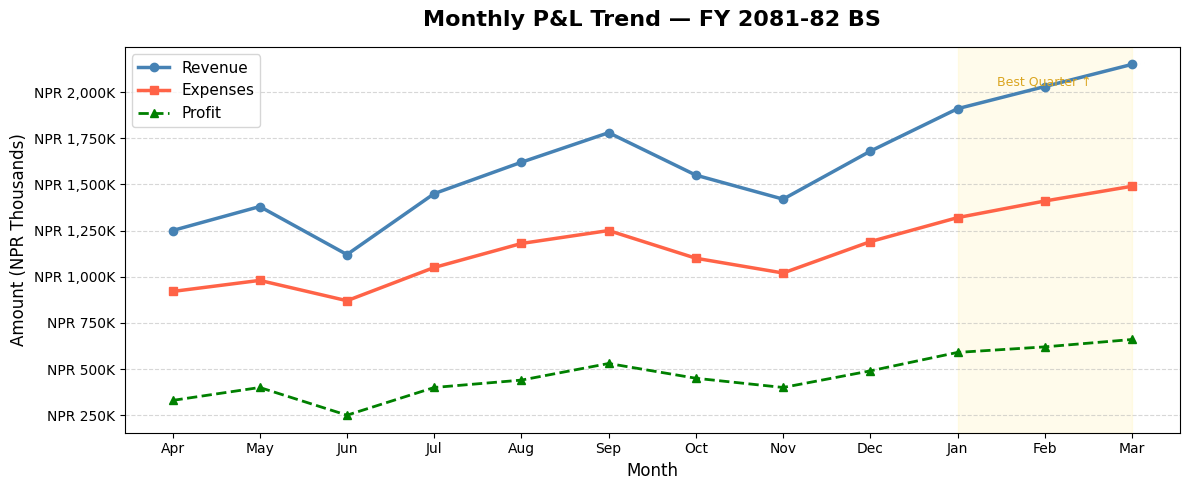

In [4]:
# Basic Line Chart
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(months, revenue, color='steelblue', linewidth=2.5, marker='o', markersize=6, label='Revenue')
ax.plot(months, expenses, color='tomato',   linewidth=2.5, marker='s', markersize=6, label='Expenses')
ax.plot(months, profit,   color='green',    linewidth=2.0, marker='^', markersize=6, label='Profit', linestyle='--')

# Labels and title
ax.set_title('Monthly P&L Trend — FY 2081-82 BS', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Amount (NPR Thousands)', fontsize=12)

# Legend and grid
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Format y-axis to show NPR  symbol
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'NPR {x:,.0f}K'))

# Add shaded region to highlight Q4
ax.axvspan(9, 11, alpha=0.08, color='gold', label='Q4')
ax.annotate('Best Quarter ↑', xy=(10, 2030), fontsize=9, color='goldenrod', ha='center')

plt.tight_layout()
plt.show()

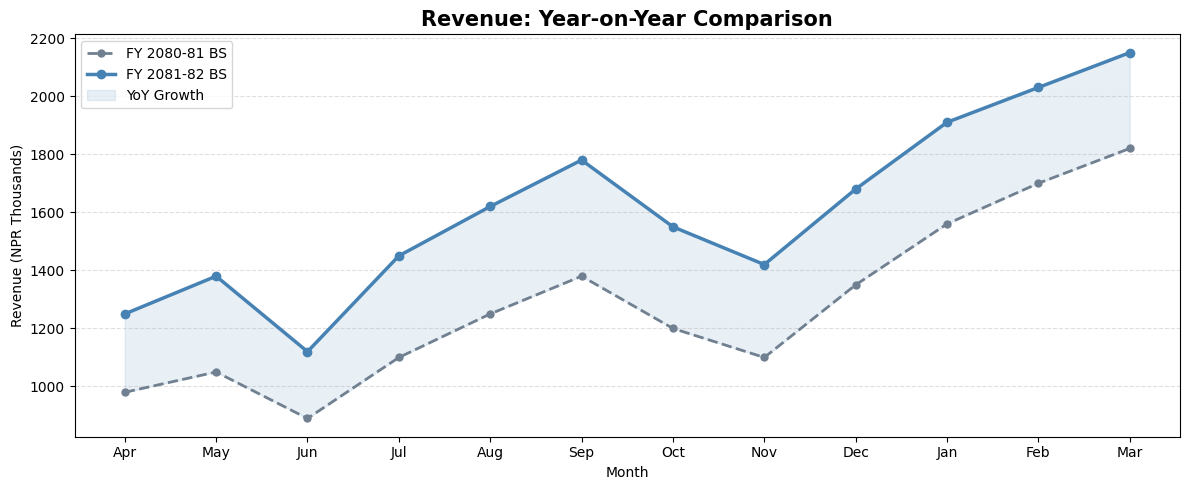

In [5]:
# Year-on-Year Comparison Line Chart
fy24_revenue = [980, 1050, 890, 1100, 1250, 1380, 1200, 1100, 1350, 1560, 1700, 1820]
fy25_revenue = [1250, 1380, 1120, 1450, 1620, 1780, 1550, 1420, 1680, 1910, 2030, 2150]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(months, fy24_revenue, color='slategray', linewidth=2, marker='o', markersize=5,
        label='FY 2080-81 BS', linestyle='--')
ax.plot(months, fy25_revenue, color='steelblue', linewidth=2.5, marker='o', markersize=6,
        label='FY 2081-82 BS')

# Fill area between lines to highlight growth
ax.fill_between(months, fy24_revenue, fy25_revenue, alpha=0.12, color='steelblue', label='YoY Growth')

ax.set_title('Revenue: Year-on-Year Comparison', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (NPR Thousands)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Section 9: Bar Chart — Expense Comparison

Bar charts are ideal for **comparing categories** — expense heads, client revenues, department budgets.

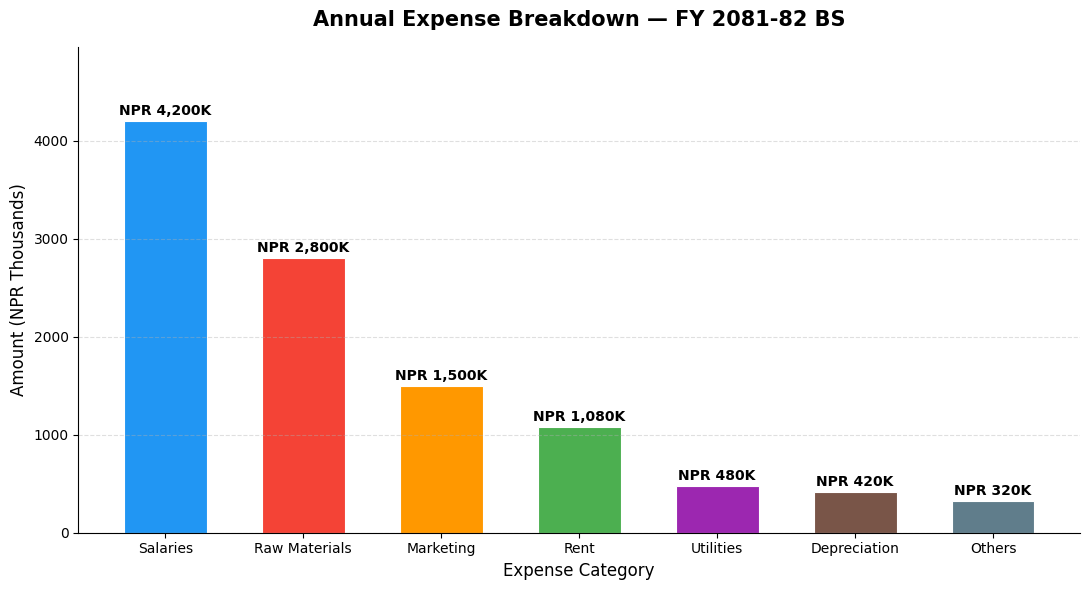

In [6]:
# Vertical Bar Chart — Annual Expenses by Category
colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50', '#9C27B0', '#795548', '#607D8B']

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(expense_categories, expense_values, color=colors, edgecolor='white', linewidth=0.8, width=0.6)

# Add value labels on top of each bar
for bar, val in zip(bars, expense_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'NPR {val:,}K', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Annual Expense Breakdown — FY 2081-82 BS', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Expense Category', fontsize=12)
ax.set_ylabel('Amount (NPR Thousands)', fontsize=12)
ax.set_ylim(0, max(expense_values) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Section 10: Horizontal Bar Chart

Horizontal bars work better when category names are long — like account names or client names.

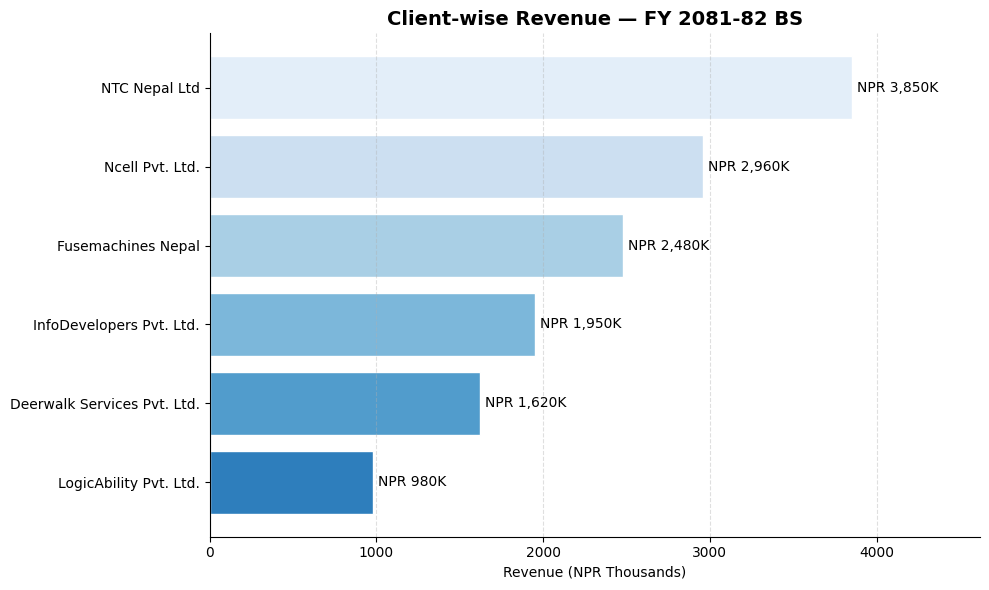

In [7]:
# Horizontal Bar — Client Revenue Contribution
clients = ['NTC Nepal Ltd', 'Ncell Pvt. Ltd.', 'Fusemachines Nepal',
           'InfoDevelopers Pvt. Ltd.', 'Deerwalk Services Pvt. Ltd.', 'LogicAbility Pvt. Ltd.']
client_revenue = [3850, 2960, 2480, 1950, 1620, 980]   # NPR  Thousands

# Sort for better visual
sorted_pairs = sorted(zip(client_revenue, clients))
client_revenue_s, clients_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(clients_s, client_revenue_s,
               color=plt.cm.Blues_r(np.linspace(0.3, 0.9, len(clients_s))),
               edgecolor='white')

for bar, val in zip(bars, client_revenue_s):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'NPR {val:,}K', va='center', fontsize=10)

ax.set_title('Client-wise Revenue — FY 2081-82 BS', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (NPR Thousands)')
ax.set_xlim(0, max(client_revenue_s) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Section 11: Grouped Bar Chart — Budget vs Actual

Grouped bars are perfect for **comparing two or more related series side by side** — like Budget vs Actual, or FY 2081 BS vs FY 2082 BS per department.

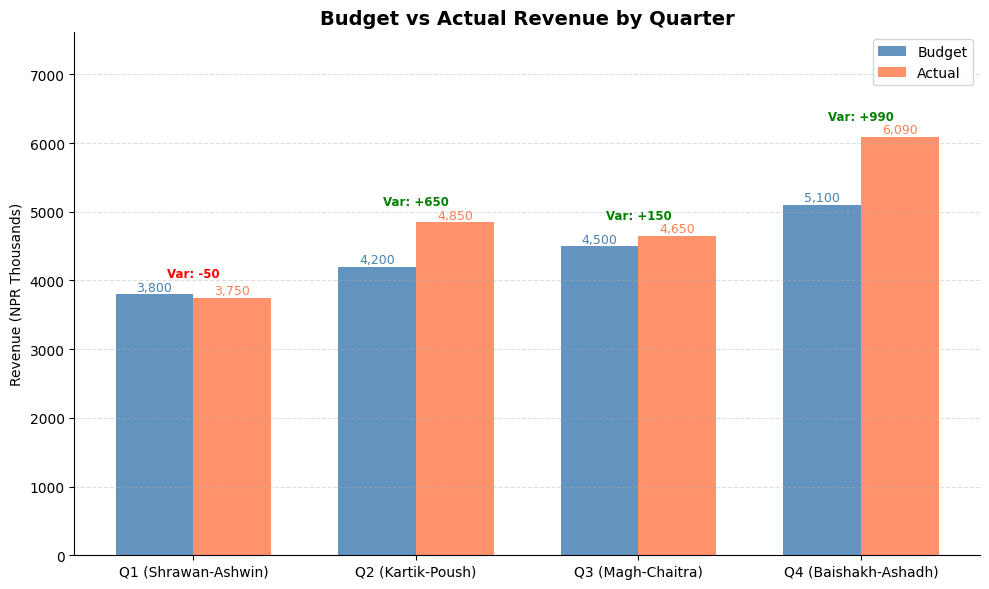

In [8]:
# Budget vs Actual by Quarter
quarters      = ['Q1 (Shrawan-Ashwin)', 'Q2 (Kartik-Poush)', 'Q3 (Magh-Chaitra)', 'Q4 (Baishakh-Ashadh)']
budget_qtly   = [3800, 4200, 4500, 5100]   # NPR  Thousands
actual_qtly   = [3750, 4850, 4650, 6090]

x = np.arange(len(quarters))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, budget_qtly, width, label='Budget', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, actual_qtly, width, label='Actual', color='coral', alpha=0.85)

# Labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', fontsize=9, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', fontsize=9, color='coral')

# Variance annotation
for i, (b, a) in enumerate(zip(budget_qtly, actual_qtly)):
    variance = a - b
    color = 'green' if variance >= 0 else 'red'
    sign  = '+' if variance >= 0 else ''
    ax.text(i, max(b, a) + 250, f'Var: {sign}{variance:,}', ha='center',
            fontsize=8.5, color=color, fontweight='bold')

ax.set_title('Budget vs Actual Revenue by Quarter', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (NPR Thousands)')
ax.set_xticks(x)
ax.set_xticklabels(quarters)
ax.legend()
ax.set_ylim(0, max(actual_qtly) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Section 12: Pie & Donut Chart — Revenue or Expense Mix

Pie charts show **part-to-whole relationships** — revenue by business segment, expenses by head.

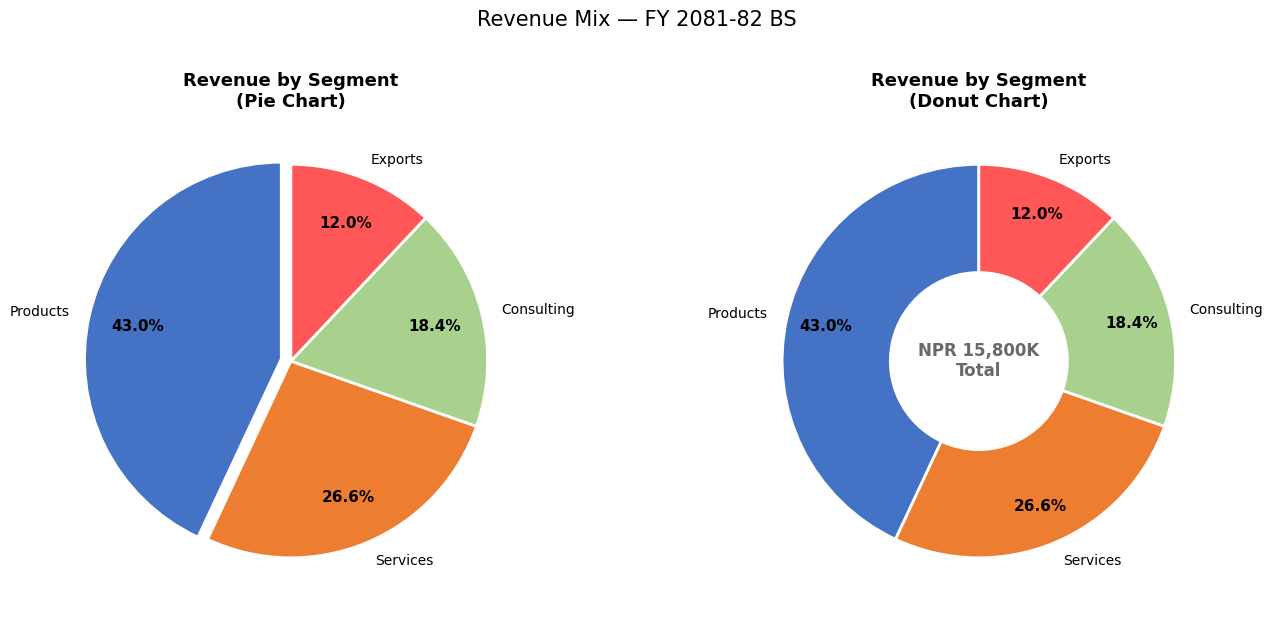

In [9]:
# Pie Chart — Revenue by Business Segment
segments = ['Products', 'Services', 'Consulting', 'Exports']
seg_vals  = [6800, 4200, 2900, 1900]   # NPR  Thousands
colors    = ['#4472C4', '#ED7D31', '#A9D18E', '#FF5757']
explode   = [0.05, 0, 0, 0]   # Slightly separate the largest segment

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Pie Chart ---
wedges, texts, autotexts = axes[0].pie(
    seg_vals, labels=segments, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
axes[0].set_title('Revenue by Segment\n(Pie Chart)', fontsize=13, fontweight='bold')

# --- Donut Chart (Pie with a hole) ---
wedges2, texts2, autotexts2 = axes[1].pie(
    seg_vals, labels=segments, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)   # width < 1 creates donut
)
for text in autotexts2:
    text.set_fontsize(11)
    text.set_fontweight('bold')

total = sum(seg_vals)
axes[1].text(0, 0, f'NPR {total:,}K\nTotal', ha='center', va='center',
             fontsize=12, fontweight='bold', color='dimgray')
axes[1].set_title('Revenue by Segment\n(Donut Chart)', fontsize=13, fontweight='bold')

plt.suptitle('Revenue Mix — FY 2081-82 BS', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Section 13: Histogram — Invoice Amount Distribution

Histograms show the **distribution / frequency** of numerical data. Useful in audit for:
- Understanding the spread of invoice values
- Identifying concentration around suspicious thresholds
- Detecting Benford's Law anomalies

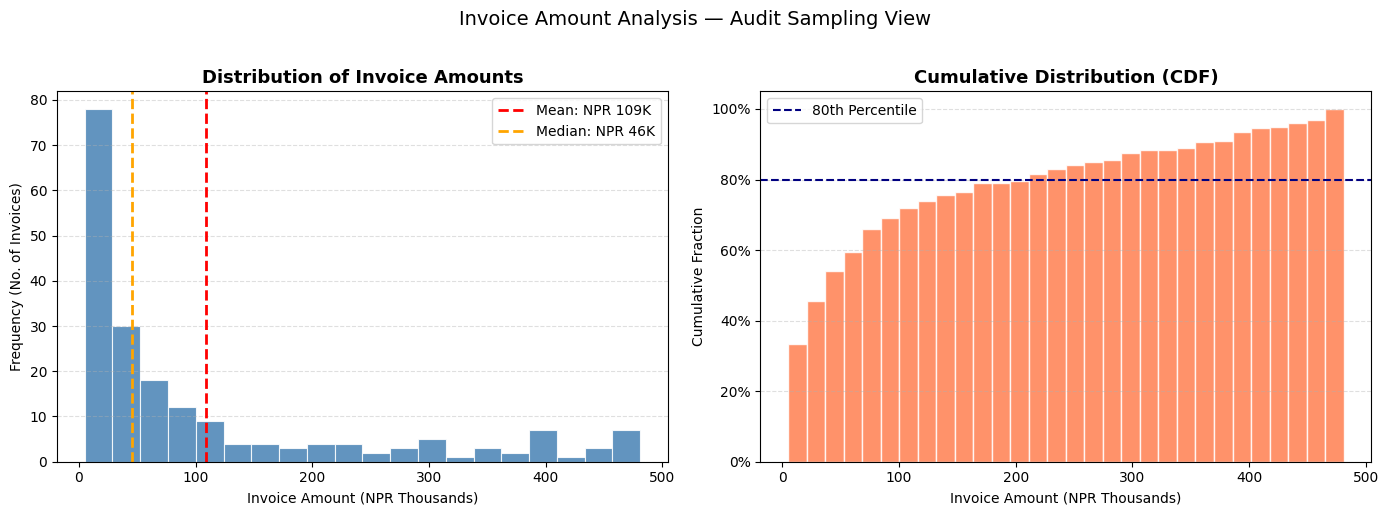

80th percentile: NPR 212,208
Invoices above NPR 212,208: 40 (20.0%) — these form the audit focus


In [10]:
# Simulate 200 invoice amounts
np.random.seed(42)
invoice_amounts = np.concatenate([
    np.random.exponential(scale=50000, size=160),   # Most invoices: small-medium
    np.random.uniform(200000, 500000, size=40)       # Some large invoices
])
invoice_amounts = np.clip(invoice_amounts, 5000, 500000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(invoice_amounts / 1000, bins=20, color='steelblue', edgecolor='white',
             alpha=0.85, linewidth=0.8)
axes[0].axvline(np.mean(invoice_amounts)/1000, color='red', linestyle='--',
                linewidth=2, label=f'Mean: NPR {np.mean(invoice_amounts)/1000:.0f}K')
axes[0].axvline(np.median(invoice_amounts)/1000, color='orange', linestyle='--',
                linewidth=2, label=f'Median: NPR {np.median(invoice_amounts)/1000:.0f}K')
axes[0].set_title('Distribution of Invoice Amounts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Invoice Amount (NPR Thousands)')
axes[0].set_ylabel('Frequency (No. of Invoices)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Cumulative histogram — shows what % of invoices are below a value
axes[1].hist(invoice_amounts / 1000, bins=30, cumulative=True, density=True,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].axhline(0.8, color='navy', linestyle='--', linewidth=1.5, label='80th Percentile')
axes[1].set_title('Cumulative Distribution (CDF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Invoice Amount (NPR Thousands)')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

plt.suptitle('Invoice Amount Analysis — Audit Sampling View', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

p80 = np.percentile(invoice_amounts, 80)
above_p80 = np.sum(invoice_amounts > p80)
print(f'80th percentile: NPR {p80:,.0f}')
print(f'Invoices above NPR {p80:,.0f}: {above_p80} ({above_p80/len(invoice_amounts)*100:.1f}%) — these form the audit focus')

## Section 14: Scatter Plot — Profit vs Revenue Relationship

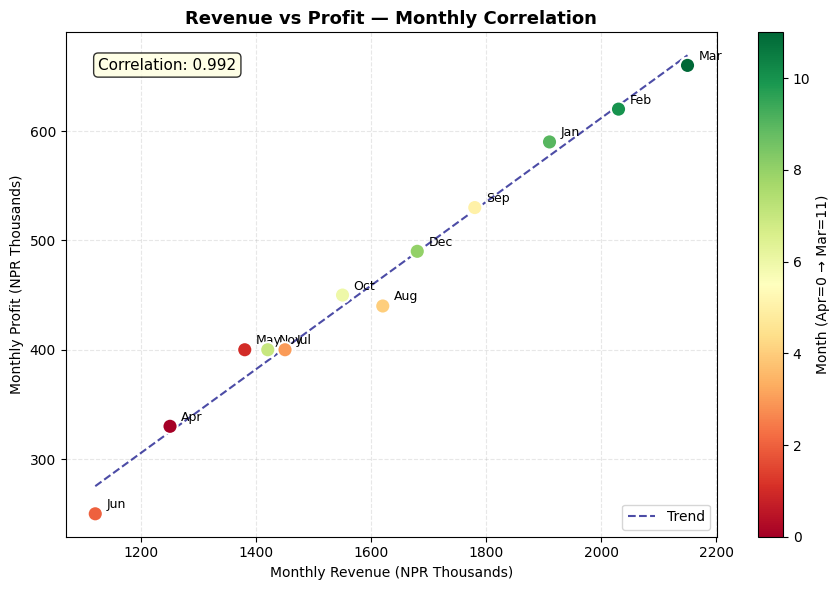

In [11]:
# Scatter plot — Monthly Revenue vs Profit
revenue_arr = np.array(revenue)
profit_arr  = np.array(profit)

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(revenue_arr, profit_arr,
                     c=range(12), cmap='RdYlGn', s=120, zorder=5, edgecolors='white', linewidth=1.5)

# Label each point with month name
for i, month in enumerate(months):
    ax.annotate(month, (revenue_arr[i], profit_arr[i]),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

# Add trend line
z = np.polyfit(revenue_arr, profit_arr, 1)
p = np.poly1d(z)
x_line = np.linspace(min(revenue_arr), max(revenue_arr), 100)
ax.plot(x_line, p(x_line), 'navy', linestyle='--', linewidth=1.5, label='Trend', alpha=0.7)

plt.colorbar(scatter, ax=ax, label='Month (Apr=0 → Mar=11)')
ax.set_title('Revenue vs Profit — Monthly Correlation', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Revenue (NPR Thousands)')
ax.set_ylabel('Monthly Profit (NPR Thousands)')
ax.grid(linestyle='--', alpha=0.3)
ax.legend()

corr = np.corrcoef(revenue_arr, profit_arr)[0, 1]
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## Section 15: Subplots — Building a Financial Dashboard

Subplots let you display **multiple charts on one page** — like a management dashboard.

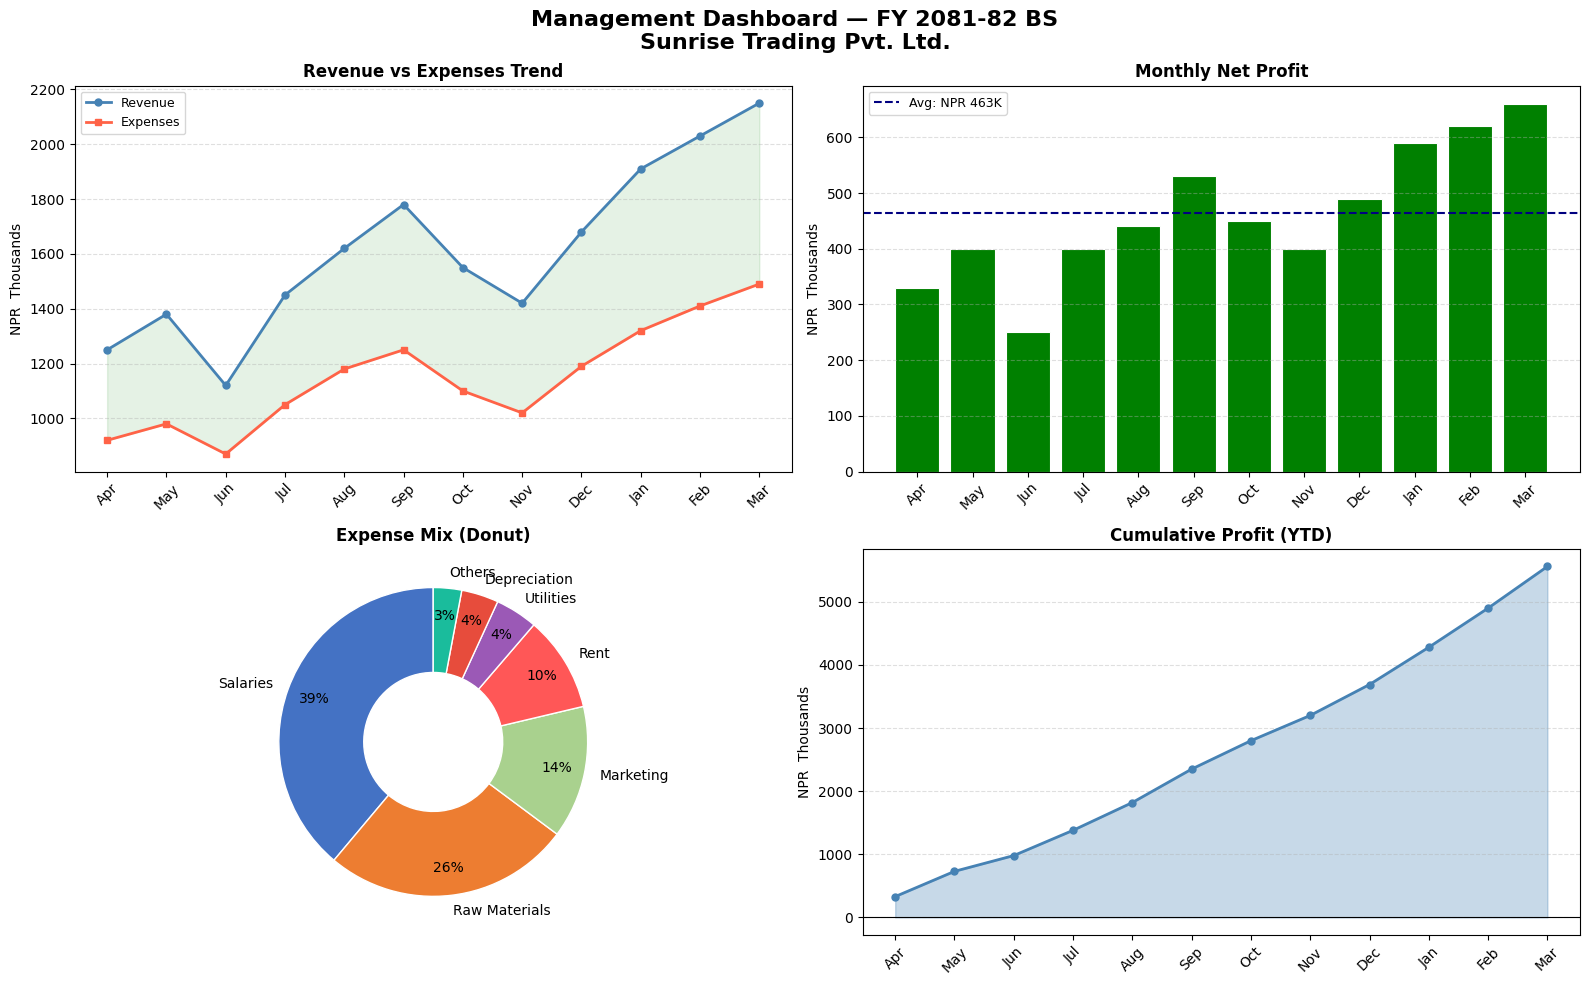

In [12]:
# 2×2 Financial Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Management Dashboard — FY 2081-82 BS\nSunrise Trading Pvt. Ltd.', fontsize=16, fontweight='bold', y=0.98)

# ── Chart 1 (top-left): Revenue & Expense trend ──
axes[0, 0].plot(months, revenue, 'steelblue', marker='o', markersize=5, linewidth=2, label='Revenue')
axes[0, 0].plot(months, expenses, 'tomato', marker='s', markersize=5, linewidth=2, label='Expenses')
axes[0, 0].fill_between(months, expenses, revenue, alpha=0.1, color='green')
axes[0, 0].set_title('Revenue vs Expenses Trend', fontweight='bold')
axes[0, 0].set_ylabel('NPR  Thousands')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0, 0].tick_params(axis='x', rotation=45)

# ── Chart 2 (top-right): Monthly Profit bars ──
bar_colors = ['green' if p > 0 else 'red' for p in profit]
axes[0, 1].bar(months, profit, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0, 1].axhline(np.mean(profit), color='navy', linestyle='--', linewidth=1.5,
                    label=f'Avg: NPR {np.mean(profit):,.0f}K')
axes[0, 1].set_title('Monthly Net Profit', fontweight='bold')
axes[0, 1].set_ylabel('NPR  Thousands')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)
axes[0, 1].tick_params(axis='x', rotation=45)

# ── Chart 3 (bottom-left): Expense mix donut ──
colors_pie = ['#4472C4','#ED7D31','#A9D18E','#FF5757','#9B59B6','#E74C3C','#1ABC9C']
axes[2-2, 0+2-2]  # placeholder to maintain comment alignment
axes[1, 0].pie(expense_values, labels=expense_categories, autopct='%1.0f%%',
               colors=colors_pie, startangle=90, pctdistance=0.82,
               wedgeprops=dict(width=0.55, edgecolor='white'))
axes[1, 0].set_title('Expense Mix (Donut)', fontweight='bold')

# ── Chart 4 (bottom-right): Cumulative profit ──
cum_profit = np.cumsum(profit)
axes[1, 1].fill_between(months, cum_profit, color='steelblue', alpha=0.3)
axes[1, 1].plot(months, cum_profit, color='steelblue', marker='o', markersize=5, linewidth=2)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Cumulative Profit (YTD)', fontweight='bold')
axes[1, 1].set_ylabel('NPR  Thousands')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 16: Styling & Formatting Tips

Good chart design communicates faster. Here are key formatting techniques:

Available styles (first 10): ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot']


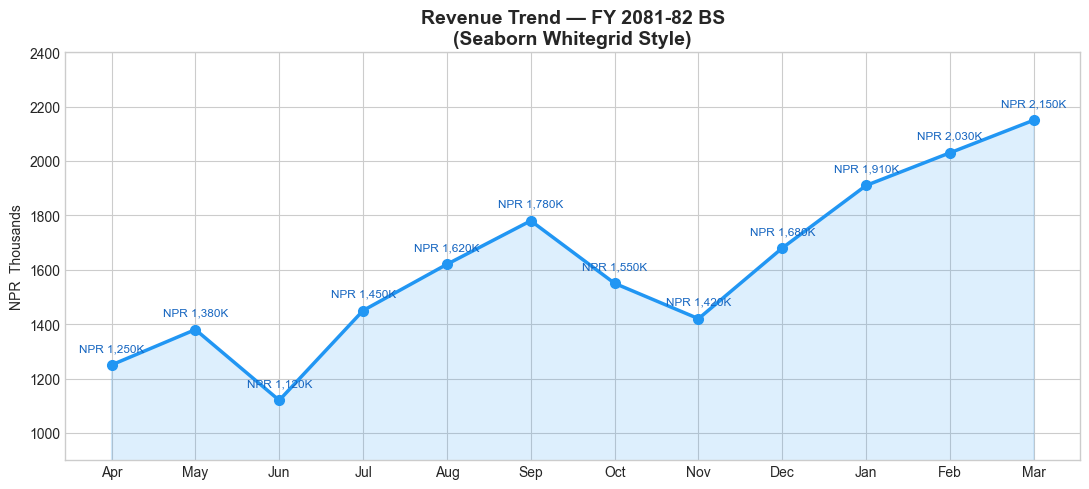

In [13]:
# Using a built-in style for a more professional look
available_styles = plt.style.available
print('Available styles (first 10):', available_styles[:10])

# Use 'seaborn-v0_8-whitegrid' for clean, publication-ready charts
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(months, revenue, marker='o', linewidth=2.5, color='#2196F3', markersize=7)
    ax.fill_between(months, revenue, alpha=0.15, color='#2196F3')

    # Add data labels on each point
    for i, (m, r) in enumerate(zip(months, revenue)):
        ax.annotate(f'NPR {r:,}K', (m, r), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8.5, color='#1565C0')

    ax.set_title('Revenue Trend — FY 2081-82 BS\n(Seaborn Whitegrid Style)', fontsize=14, fontweight='bold')
    ax.set_ylabel('NPR  Thousands')
    ax.set_ylim(900, 2400)
    plt.tight_layout()
    plt.show()

## Section 17: Saving Charts

Save charts as PNG, PDF, or SVG for reports and presentations.

Charts saved:
  revenue_trend.png  (300 DPI — for presentations)
  revenue_trend.pdf  (vector — for print/reports)


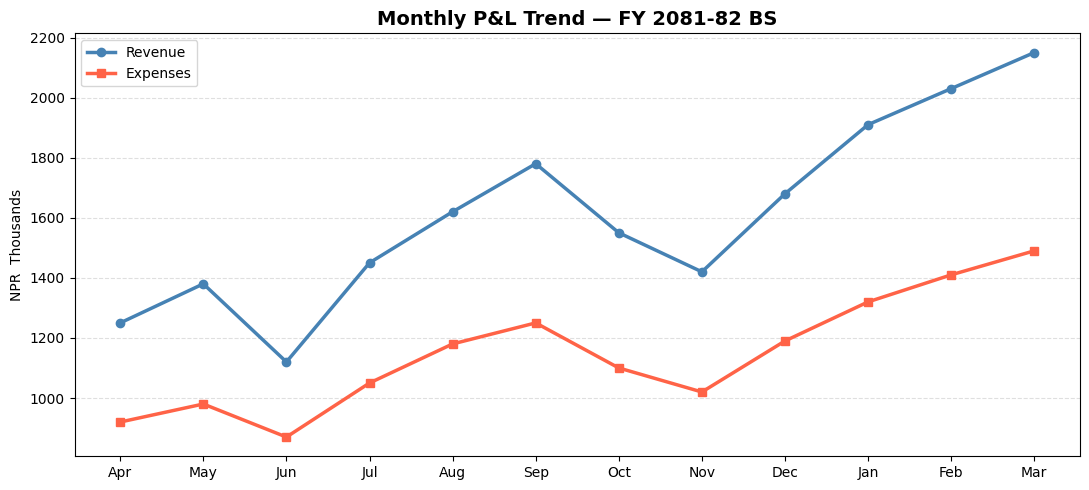

In [14]:
# Create a chart and save it
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(months, revenue, color='steelblue', marker='o', linewidth=2.5, label='Revenue')
ax.plot(months, expenses, color='tomato',   marker='s', linewidth=2.5, label='Expenses')
ax.set_title('Monthly P&L Trend — FY 2081-82 BS', fontsize=14, fontweight='bold')
ax.set_ylabel('NPR  Thousands')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# Save options:
plt.savefig('revenue_trend.png', dpi=300, bbox_inches='tight')       # High-res PNG
plt.savefig('revenue_trend.pdf', bbox_inches='tight')                 # PDF (vector)

print('Charts saved:')
print('  revenue_trend.png  (300 DPI — for presentations)')
print('  revenue_trend.pdf  (vector — for print/reports)')

plt.show()

## Section 18: Practice Exercises

---

#### 🏋️ Exercise 1 — Stacked Bar: Quarterly Cost Structure

Create a **stacked bar chart** showing quarterly expense breakdown across 4 categories:
```python
quarters    = ['Q1 (Shrawan-Ashwin)', 'Q2 (Kartik-Poush)', 'Q3 (Magh-Chaitra)', 'Q4 (Baishakh-Ashadh)']
salaries    = [1200, 1250, 1280, 1350]   # NPR  Thousands
materials   = [800,  950,  880,  1050]
overheads   = [320,  345,  330,  380]
marketing   = [180,  210,  195,  260]
```
Requirements: Add a title, legend, value labels on each segment, and y-axis label.

In [15]:
import matplotlib.pyplot as plt
import numpy as np

quarters  = ['Q1 (Shrawan-Ashwin)', 'Q2 (Kartik-Poush)', 'Q3 (Magh-Chaitra)', 'Q4 (Baishakh-Ashadh)']
salaries  = [1200, 1250, 1280, 1350]
materials = [800,  950,  880, 1050]
overheads = [320,  345,  330,  380]
marketing = [180,  210,  195,  260]

# Hint: Use ax.bar(..., bottom=...) to stack bars
# Each subsequent bar's bottom = sum of all previous categories



#### 🏋️ Exercise 2 — Waterfall Chart: P&L Bridge

A waterfall chart shows how you get from Revenue to Net Profit — extremely common in management presentations and earnings calls.

Build one using bar charts with this data:
- Revenue: NPR 18,000K
- Less COGS: NPR 10,800K
- = Gross Profit: NPR 7,200K
- Less Opex: NPR 3,300K
- Less Depreciation: NPR 420K
- Less Finance Cost: NPR 216K
- = Net Profit Before Tax: NPR 3,264K

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Hint: For a waterfall chart:
# - Positive items (Revenue, Gross Profit, Net Profit) = green/blue bars from 0
# - Negative items (COGS, Opex, etc.) = red bars sitting on top of running total
# - Use 'bottom' parameter in ax.bar() to position bars correctly

items  = ['Revenue', 'COGS', 'Gross\nProfit', 'Opex', 'Depreciation', 'Finance\nCost', 'Net Profit\nBefore Tax']
values = [18000, -10800, 7200, -3300, -420, -216, 3264]   # NPR  Thousands



---
### 💡 Solutions

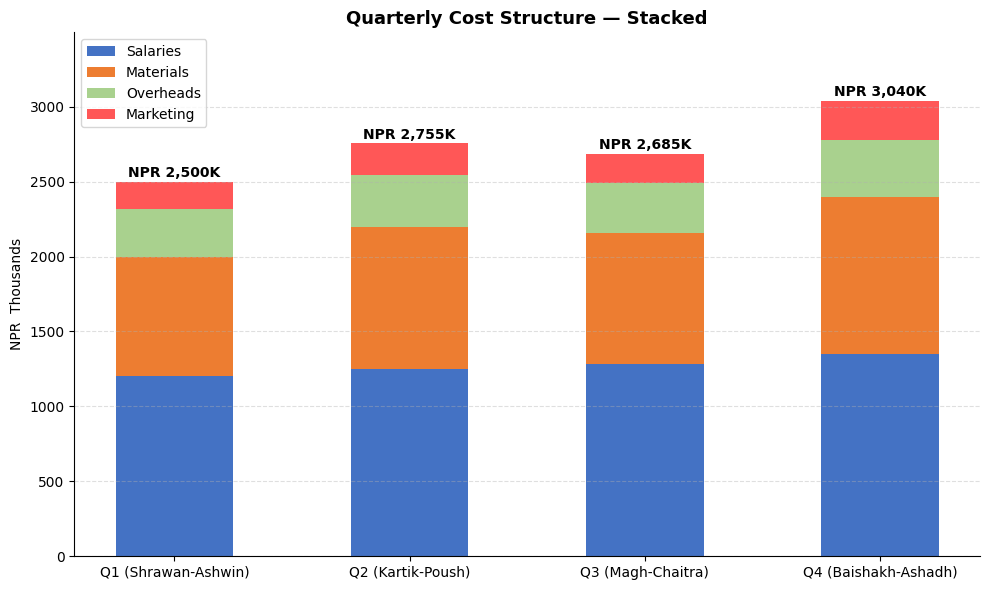

In [17]:
# SOLUTION — Exercise 1: Stacked Bar Chart
import matplotlib.pyplot as plt
import numpy as np

quarters  = ['Q1 (Shrawan-Ashwin)', 'Q2 (Kartik-Poush)', 'Q3 (Magh-Chaitra)', 'Q4 (Baishakh-Ashadh)']
salaries  = np.array([1200, 1250, 1280, 1350])
materials = np.array([800,  950,  880, 1050])
overheads = np.array([320,  345,  330,  380])
marketing = np.array([180,  210,  195,  260])

fig, ax = plt.subplots(figsize=(10, 6))

b1 = ax.bar(quarters, salaries,  label='Salaries',   color='#4472C4', width=0.5)
b2 = ax.bar(quarters, materials, label='Materials',  color='#ED7D31', width=0.5, bottom=salaries)
b3 = ax.bar(quarters, overheads, label='Overheads',  color='#A9D18E', width=0.5, bottom=salaries+materials)
b4 = ax.bar(quarters, marketing, label='Marketing',  color='#FF5757', width=0.5, bottom=salaries+materials+overheads)

# Total labels on top
totals = salaries + materials + overheads + marketing
for i, total in enumerate(totals):
    ax.text(i, total + 30, f'NPR {total:,}K', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Quarterly Cost Structure — Stacked', fontsize=13, fontweight='bold')
ax.set_ylabel('NPR  Thousands')
ax.set_ylim(0, max(totals) * 1.15)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

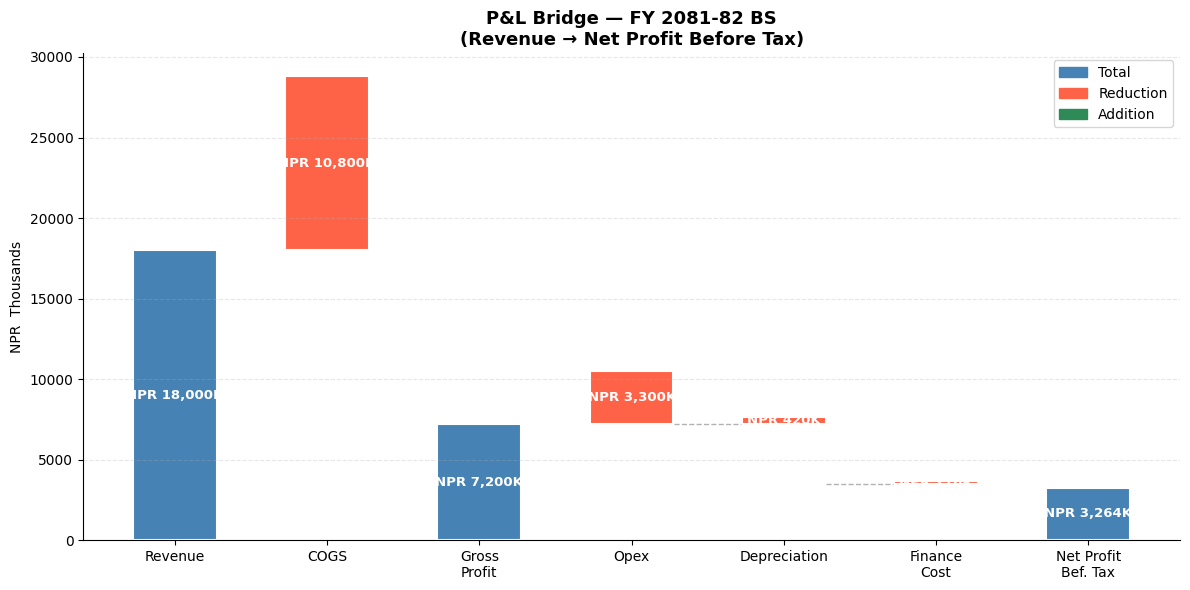

In [18]:
# SOLUTION — Exercise 2: Waterfall / P&L Bridge Chart
import matplotlib.pyplot as plt
import numpy as np

items  = ['Revenue', 'COGS', 'Gross\nProfit', 'Opex', 'Depreciation', 'Finance\nCost', 'Net Profit\nBef. Tax']
values = [18000, -10800, 7200, -3300, -420, -216, 3264]

# Calculate running totals to position bars
subtotals = [0, 18000, 18000, 7200, 7200, 3900-420, 3480-216]
# For absolute bars (Revenue, Gross Profit, Net Profit)
absolute_items = {0, 2, 6}

bottoms = []
for i, (item, val) in enumerate(zip(items, values)):
    if i in absolute_items:
        bottoms.append(0)
    else:
        bottoms.append(subtotals[i])

colors = []
for i, val in enumerate(values):
    if i in absolute_items:
        colors.append('steelblue')
    elif val > 0:
        colors.append('seagreen')
    else:
        colors.append('tomato')

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(items, [abs(v) for v in values], bottom=bottoms,
              color=colors, edgecolor='white', linewidth=1.5, width=0.55)

# Value labels
for bar, val, bot in zip(bars, values, bottoms):
    label = f'NPR {abs(val):,}K'
    y_pos = bot + abs(val) / 2
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label,
            ha='center', va='center', fontsize=9.5, fontweight='bold', color='white')

# Connector lines
for i in range(len(items) - 1):
    if i not in absolute_items and i+1 not in absolute_items:
        ax.plot([i + 0.28, i + 0.72], [bottoms[i+1], bottoms[i+1]],
                color='gray', linewidth=1, linestyle='--', alpha=0.6)

ax.set_title('P&L Bridge — FY 2081-82 BS\n(Revenue → Net Profit Before Tax)', fontsize=13, fontweight='bold')
ax.set_ylabel('NPR  Thousands')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Total'),
                   Patch(color='tomato',    label='Reduction'),
                   Patch(color='seagreen',  label='Addition')])
plt.tight_layout()
plt.show()

---
## 🎉 Module 4 Complete!

### What you've learned
| Chart Type | When to Use |
|------------|-------------|
| Line Chart | Revenue/profit trends over time |
| Bar Chart | Comparing categories (expenses, clients) |
| Horizontal Bar | Long category names, rankings |
| Grouped Bar | Budget vs Actual, year-on-year |
| Stacked Bar | Cost structure, segment contribution |
| Pie / Donut | Revenue mix, expense breakdown |
| Histogram | Invoice distribution, audit sampling |
| Scatter Plot | Relationships, correlation analysis |
| Waterfall | P&L bridge, variance explanation |
| Subplots | Management dashboards |

**Next up → Module 5: Seaborn** — Statistical charts with even less code!

---
*Python for CA Professionals — Module 4: Matplotlib*